# ARCHON Day 2026

**ADAF workshop**

---

Nejc Čož

ZRC SAZU, Ljubljana, Slovenia

**Utrecht, 17. 4. 2026**


---

**Automatic detection of archaeological features**

This tutorial notebook shows how to use ADAF to detect archaeological features from lidar data. You will work through examples focused on barrows and mounds, based on case studies from Ireland (TII ADAF project) and Bosnia and Herzegovina (ERC STONE project).

<ins>Note</ins>: If you use this notebook or ADAF software in research, we ecourage you to cite the following article:

> Čož, N., Corns, A., Curran, S., Kocev, D., Kokalj, Ž., 2026. Automatic detection of archaeological features from airborne laser scanning data using deep learning: Development and evaluation of the ADAF tool. Journal of Archaeological Science: Reports 71, 105733. https://doi.org/10.1016/j.jasrep.2026.105733


**Acknowledgments**

The research was funded by Transport Infrastructure Ireland Open Research Call 2021 and by the Slovenian Research and Innovation Agency core funding Earth observation and geoinformatics (P2-0406). It was also funded by the European Union (ERC, STONE, 101089123).

# 1 How to begin

Before starting the tutorial:

1. Download the required data from:
   - https://oblak.zrc-sazu.si/index.php/s/XrwmPnkyLHK6DBx
   - https://zenodo.org/records/15848663

2. Upload the data to a folder in your Google Drive, for example:
   `MyDrive/archon-adaf`

3. In the menu bar, go to **Runtime** → **Change runtime type**.

4. Set the hardware accelerator to **T4 GPU** and click **Save**.


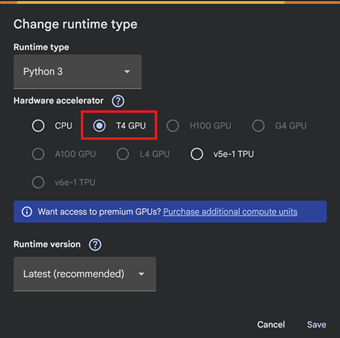!

**Make your Google Drive folder available in Google Colab**

Run the next cell to mount your Google Drive, so that Colab can access the workshop files stored there.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

**Root folder**

Create a variable pointing to your root folder.

In [ ]:
root = "/content/drive/MyDrive/archon-adaf"

**Make the ADAF module available to this Notebook**

Clone the ADAF repository from GitHub into your Google Drive.

> **Important**
>
> Check the target path carefully.
>
> For example, if your workshop folder is:
>
> `/content/drive/MyDrive/archon-adaf`
>
> then the repository should be cloned to:
>
> `/content/drive/MyDrive/archon-adaf/adaf`
>
> This will place the ADAF code inside your workshop folder and keep all files in one location.


In [ ]:
!git clone --branch demo/adaf-lite --single-branch \
    https://github.com/EarthObservation/adaf.git \
    "{root}/adaf"

**Make the `ml_models` folder available to ADAF**

Run the next cell to make the `ml_models` folder available at the location expected by ADAF.

> This command creates a symbolic link, which acts as a pointer to another folder rather than copying the files.

In [ ]:
!rm -rf "{root}/adaf/adaf/ml_models"
!ln -s "{root}/ml_models" "{root}/adaf/adaf/ml_models"

**Install the required dependencies**

Run the next cell to install required Python packages missing from the Google Colab environment.

In [ ]:
!pip install -q rvt-py

Now that everything is set up, we can begin processing the data.

---


# 2 ADAF tutorial

This notebook shows how to run ADAF without the GUI. Instead, the workflow is controlled directly from Python cells in Jupyter Notebook.

- All processing is run through the `main_routine` function imported from the `adaf` module.
- Parameters are passed to `main_routine` using the `ADAFInput` object.

In [ ]:
import sys
sys.path.append(f"{root}/adaf")

from adaf.adaf_inference import main_routine
from adaf.adaf_utils import ADAFInput

`ADAFInput` is the notebook equivalent of the GUI input form. It is a Python object that stores all parameters required for running ADAF.

To see which parameters are available, run the next cell.

In [ ]:
available_inputs = ADAFInput()
available_inputs.__dict__

## 2.1 Input parameters

In this step, you will prepare the input parameters for the experiment.

- Two example datasets are available in this tutorial: one from Ireland and one from Bosnia and Herzegovina. We will define paths for both, so you can easily switch between them.
- In this tutorial, the selected machine learning method is `segmentation`.
- For post-processing, set the minimum roundness to `0.75` and the minimum area to `30` m².
- All other parameters can remain at their default values.

Explanation of selected parameters:

**Machine learning options**

`ml_type`:
- `"segmentation"`
- `"object detection"`

`labels`:
- `"AO"` (for All archaeology)
- `"barrow"`
- `"ringfort"`
- `"enclosure"`

> **Reminder:** Update the input path so that it matches the location of your raster file in Google Drive.


In [ ]:
# Input DEMs
dem_ireland = f"{root}/dfm_Ireland/ISA-88_Gorteen_dem_05m.vrt"
dem_bih = f"{root}/dfm_BiH/BiH_ALS_2025_clipped.tif"

# # Or enter full path as a string:
# dem_ireland = "/content/drive/MyDrive/archon-adaf/dfm_Ireland/ISA-88_Gorteen_dem_05m.vrt"
# dem_bih = "/content/drive/MyDrive/archon-adaf/dfm_BiH/BiH_ALS_2025_clipped.tif"

# ML type
ml_type = "segmentation"

# Post-processing parameters
roundness=0.75
min_area=30

# Create input instance
my_input = ADAFInput()

# Add the selected parametes
my_input.update(
    ml_type=ml_type,
    roundness=roundness,
    min_area=min_area
)

## 2.2 Running ADAF

In this step, you will pack the selected parameters into an `ADAFInput` object and run `main_routine`.

The results are saved to a new folder in the same parent directory as the input raster. The folder name is built from:
- the input file name,
- a date and time stamp,
- and the machine learning method suffix (`seg` for semantic segmentation, `obj` for object detection)

Example:

`my-area-dem_20231201_143215_seg`

The `main_routine` function returns the path to the output vector file.

### RUN 1: Ireland

First, run ADAF on the Irish example dataset using the `"AO"` (all archaeology) and `"barrow"` classes.

For this run, use the default ADAF machine learning models, which were trained for the detection of archaeological features in Irish lidar data.

In [ ]:
# Add Irish DEM and select classes
my_input.update(
    dem_path=dem_ireland,
    labels=["AO","barrow"],
)

# Run
irish_results = main_routine(my_input)

# Print path with the location of the results
print(irish_results)

### RUN 2: ADAF on the Bosnia and Herzegovina dataset

In this run, you will test how well the default ADAF model trained on Irish data transfers to a different geographic area.

Use the `barrow` class to identify burial mounds in the Bosnia and Herzegovina dataset.

In [ ]:
# Change to BiH DEM and only detect barrows
my_input.update(
    dem_path=dem_bih,
    labels=["barrow"]
)

# Run
bih_results = main_routine(my_input)

# Print path with the location of the results
print(bih_results)

### RUN 3: Running a retrained model

In the final run, you will use a model retrained specifically on the Bosnia and Herzegovina dataset.

This allows you to compare the results with those produced by the default ADAF model trained on Irish data.

In [ ]:
# Change the ML model to "Custom model"
my_input.update(
    dem_path=dem_bih,
    labels=["barrow"],
    ml_model_custom="Custom model",
    custom_model_pth=f"{root}/retrained_model_BiH/HRNet_adaf_barrow-stone.pth.tar",
)

# Run
bih_results_2 = main_routine(my_input)

# Print path with the location of the results
print(bih_results_2)

## 2.3 Results

The results generated in the previous step are saved to a new output folder in your Google Drive, in the same parent directory as the input raster.

The most important output is the result vector file in `.gpkg` format, which you can open directly in QGIS for further inspection and analysis. The output folder also contains a log file with the processing settings and summary information.

---

This project is licensed under the terms of the [Apache License 2.0](https://github.com/EarthObservation/adaf/blob/main/LICENSE.txt).

Copyright © 2026 ZRC SAZU